In [7]:
# ============================================================
# AI Innovators Lab: Student Performance Prediction
# Goal: Train an AI model that predicts whether a student is:
#       - Pass
#       - Needs Improvement
#
# Inputs:
# - Study hours
# - Attendance / absences
# - Homework / study support
#
# Dataset:
# UCI Student Performance Dataset
# Link: https://archive.ics.uci.edu/dataset/320/student%2Bperformance
#
# Camp version:
# The original dataset has many features. To make this project
# simple and meaningful for students, we use a few easy-to-
# understand features and create a Pass / Needs Improvement label.
# ============================================================

print("Welcome to the Student Performance Prediction Project!")
print("Goal: Build an AI model that predicts student performance.")



Welcome to the Student Performance Prediction Project!
Goal: Build an AI model that predicts student performance.


In [8]:
# ============================================================
# Step 1: Import required libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import requests
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries loaded successfully!")




Libraries loaded successfully!


In [9]:


# ============================================================
# Step 2 and Step 3: Download, extract, inspect, and load dataset
# ============================================================

import pandas as pd
import os

print("Loading dataset...")

# Direct raw CSV backup source
# This is the UCI Student Performance math dataset: student-mat.csv
url = "https://raw.githubusercontent.com/arunk13/MSDA-Assignments/master/IS607Fall2015/Assignment3/student-mat.csv"

try:
    data = pd.read_csv(url, sep=";")
    print("Dataset loaded successfully from online CSV!")
except Exception as e:
    print("Online loading failed.")
    print("Error:", e)

    # Backup option: use local file if manually uploaded to Colab
    if os.path.exists("student-mat.csv"):
        data = pd.read_csv("student-mat.csv", sep=";")
        print("Dataset loaded successfully from local file!")
    else:
        raise FileNotFoundError(
            "Could not load the dataset online or locally. "
            "Please upload student-mat.csv to Colab."
        )

print("Number of students:", len(data))
print("Number of columns:", len(data.columns))
print(data.head())




Loading dataset...
Dataset loaded successfully from online CSV!
Number of students: 395
Number of columns: 33
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  



In [10]:
# ============================================================
# Step 4: Create a simple camp-friendly dataset
#
# We use:
# - studytime: weekly study time category
# - absences: number of school absences
# - schoolsup: extra educational support
# - famsup: family educational support
# - paid: extra paid classes
# - G3: final grade
#
# We create the target:
# - Pass if final grade G3 >= 10
# - Needs Improvement if final grade G3 < 10
#
# In this dataset, grades are from 0 to 20.
# ============================================================

simple_data = data[["studytime", "absences", "schoolsup", "famsup", "paid", "G3"]].copy()

simple_data["performance"] = simple_data["G3"].apply(
    lambda grade: "Pass" if grade >= 10 else "Needs Improvement"
)

print("Simple dataset created!")
print(simple_data.head())


Simple dataset created!
   studytime  absences schoolsup famsup paid  G3        performance
0          2         6       yes     no   no   6  Needs Improvement
1          2         4        no    yes   no   6  Needs Improvement
2          2        10       yes     no  yes  10               Pass
3          3         2        no    yes  yes  15               Pass
4          2         4        no    yes  yes  10               Pass


In [11]:
# ============================================================
# Step 5: Explain the selected features
# ============================================================

feature_explanation = """
Feature Meaning:

studytime:
1 = less than 2 hours/week
2 = 2 to 5 hours/week
3 = 5 to 10 hours/week
4 = more than 10 hours/week

absences:
Number of school absences

schoolsup:
Extra educational support from school
yes = student receives support
no  = student does not receive support

famsup:
Family educational support
yes = student receives family support
no  = student does not receive family support

paid:
Extra paid classes
yes = student attends extra paid classes
no  = student does not attend extra paid classes

G3:
Final grade from 0 to 20

performance:
Pass or Needs Improvement
"""

print(feature_explanation)




Feature Meaning:

studytime:
1 = less than 2 hours/week
2 = 2 to 5 hours/week
3 = 5 to 10 hours/week
4 = more than 10 hours/week

absences:
Number of school absences

schoolsup:
Extra educational support from school
yes = student receives support
no  = student does not receive support

famsup:
Family educational support
yes = student receives family support
no  = student does not receive family support

paid:
Extra paid classes
yes = student attends extra paid classes
no  = student does not attend extra paid classes

G3:
Final grade from 0 to 20

performance:
Pass or Needs Improvement




Performance counts:
performance
Pass                 265
Needs Improvement    130
Name: count, dtype: int64


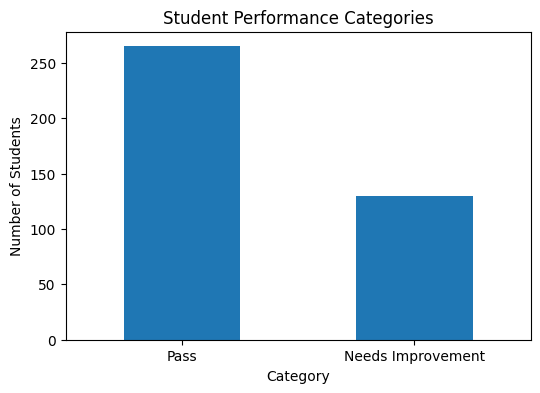

In [12]:
# ============================================================
# Step 6: Visualize Pass vs Needs Improvement
# ============================================================

print("\nPerformance counts:")
print(simple_data["performance"].value_counts())

plt.figure(figsize=(6, 4))
simple_data["performance"].value_counts().plot(kind="bar")
plt.title("Student Performance Categories")
plt.xlabel("Category")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()



In [13]:
# ============================================================
# Step 7: Convert words into numbers
#
# Machine learning models work with numbers.
# We convert:
# yes -> 1
# no  -> 0
#
# performance:
# Pass -> 1
# Needs Improvement -> 0
# ============================================================

yes_no_columns = ["schoolsup", "famsup", "paid"]

for col in yes_no_columns:
    simple_data[col] = simple_data[col].map({
        "yes": 1,
        "no": 0
    })

simple_data["performance_number"] = simple_data["performance"].map({
    "Needs Improvement": 0,
    "Pass": 1
})

print("Text converted to numbers!")
print(simple_data.head())



Text converted to numbers!
   studytime  absences  schoolsup  famsup  paid  G3        performance  \
0          2         6          1       0     0   6  Needs Improvement   
1          2         4          0       1     0   6  Needs Improvement   
2          2        10          1       0     1  10               Pass   
3          3         2          0       1     1  15               Pass   
4          2         4          0       1     1  10               Pass   

   performance_number  
0                   0  
1                   0  
2                   1  
3                   1  
4                   1  


In [14]:
# ============================================================
# Step 8: Select input features and target label
#
# X = information we give to the AI
# y = what we want the AI to predict
# ============================================================

X = simple_data[["studytime", "absences", "schoolsup", "famsup", "paid"]]
y = simple_data["performance_number"]

print("Input features:")
print(X.head())

print("\nTarget labels:")
print(y.head())



Input features:
   studytime  absences  schoolsup  famsup  paid
0          2         6          1       0     0
1          2         4          0       1     0
2          2        10          1       0     1
3          3         2          0       1     1
4          2         4          0       1     1

Target labels:
0    0
1    0
2    1
3    1
4    1
Name: performance_number, dtype: int64


In [15]:
# ============================================================
# Step 9: Split data into training and testing sets
#
# Training data teaches the AI.
# Testing data checks whether the AI learned well.
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training examples:", len(X_train))
print("Testing examples:", len(X_test))



Training examples: 296
Testing examples: 99


In [16]:
# ============================================================
# Step 10: Build and train the AI model
#
# We use a Decision Tree Classifier.
# It is beginner-friendly because it works like a set of
# "if-then" questions.
# ============================================================

model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed!")



Model training completed!


In [17]:
# ============================================================
# Step 11: Evaluate the model
# ============================================================

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Needs Improvement", "Pass"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Model Accuracy: 61.62 %

Classification Report:
                   precision    recall  f1-score   support

Needs Improvement       0.42      0.42      0.42        33
             Pass       0.71      0.71      0.71        66

         accuracy                           0.62        99
        macro avg       0.57      0.57      0.57        99
     weighted avg       0.62      0.62      0.62        99


Confusion Matrix:
[[14 19]
 [19 47]]


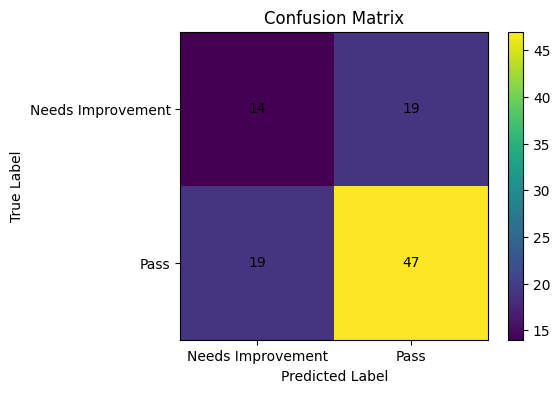

In [18]:
# ============================================================
# Step 12: Visualize the confusion matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0, 1], ["Needs Improvement", "Pass"])
plt.yticks([0, 1], ["Needs Improvement", "Pass"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()



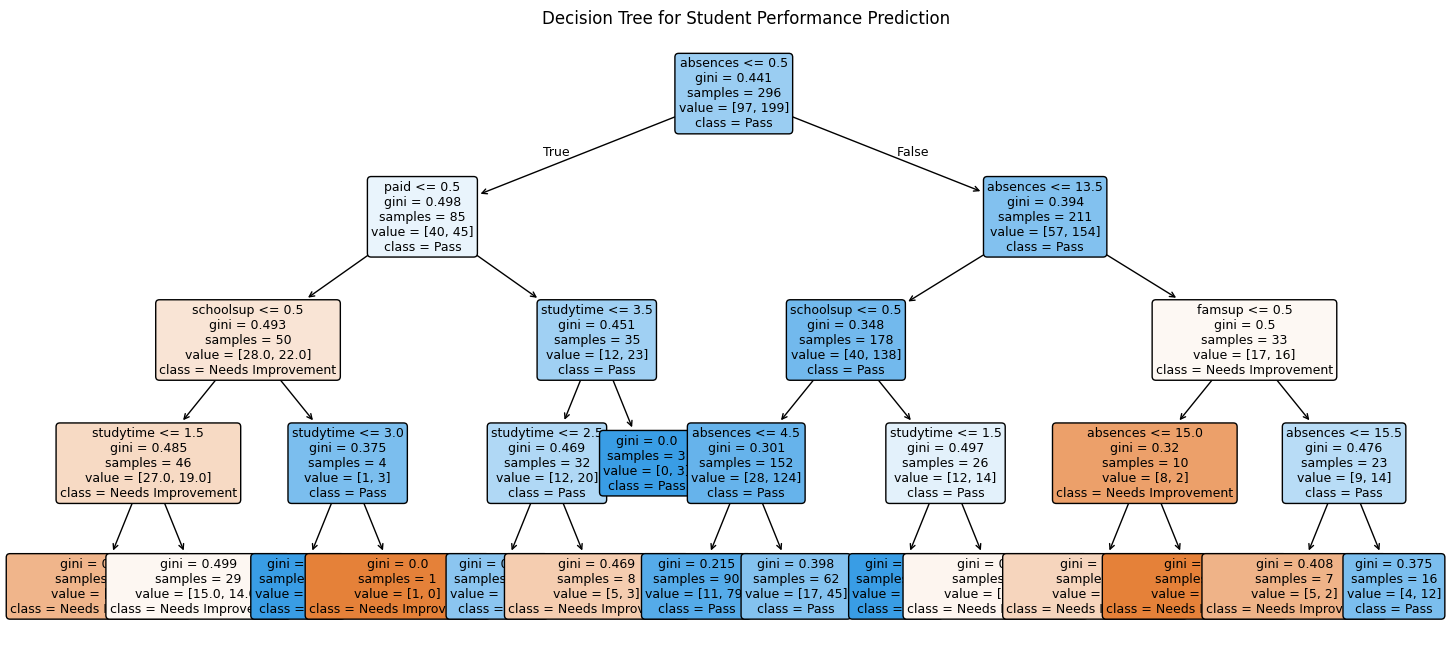

In [19]:
# ============================================================
# Step 13: Visualize the decision tree
#
# This helps students see how the model makes decisions.
# ============================================================

plt.figure(figsize=(18, 8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Needs Improvement", "Pass"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree for Student Performance Prediction")
plt.show()



In [20]:
# ============================================================
# Step 14: Test the model with custom student examples
#
# Students can change these examples and see how prediction changes.
#
# studytime:
# 1 = <2 hours/week
# 2 = 2-5 hours/week
# 3 = 5-10 hours/week
# 4 = >10 hours/week
#
# schoolsup, famsup, paid:
# 1 = yes
# 0 = no
# ============================================================

custom_students = pd.DataFrame([
    {
        "studytime": 1,
        "absences": 12,
        "schoolsup": 0,
        "famsup": 0,
        "paid": 0
    },
    {
        "studytime": 3,
        "absences": 2,
        "schoolsup": 1,
        "famsup": 1,
        "paid": 1
    },
    {
        "studytime": 2,
        "absences": 5,
        "schoolsup": 0,
        "famsup": 1,
        "paid": 0
    }
])

custom_predictions = model.predict(custom_students)
custom_probabilities = model.predict_proba(custom_students)

print("Custom Student Predictions:\n")

for i in range(len(custom_students)):
    prediction = custom_predictions[i]
    confidence = max(custom_probabilities[i]) * 100

    label = "Pass" if prediction == 1 else "Needs Improvement"

    print("Student Example", i + 1)
    print(custom_students.iloc[i])
    print("Prediction:", label)
    print("Confidence:", round(confidence, 2), "%")
    print("-" * 60)



Custom Student Predictions:

Student Example 1
studytime     1
absences     12
schoolsup     0
famsup        0
paid          0
Name: 0, dtype: int64
Prediction: Pass
Confidence: 72.58 %
------------------------------------------------------------
Student Example 2
studytime    3
absences     2
schoolsup    1
famsup       1
paid         1
Name: 1, dtype: int64
Prediction: Needs Improvement
Confidence: 52.17 %
------------------------------------------------------------
Student Example 3
studytime    2
absences     5
schoolsup    0
famsup       1
paid         0
Name: 2, dtype: int64
Prediction: Pass
Confidence: 72.58 %
------------------------------------------------------------


In [21]:
# ============================================================
# Step 15: Let students enter their own values
# ============================================================

print("Now test your own student example.")
print("For studytime, choose:")
print("1 = less than 2 hours/week")
print("2 = 2 to 5 hours/week")
print("3 = 5 to 10 hours/week")
print("4 = more than 10 hours/week")

student_studytime = int(input("Enter studytime (1, 2, 3, or 4): "))
student_absences = int(input("Enter number of absences: "))

student_schoolsup = input("Extra school support? (yes/no): ").lower()
student_famsup = input("Family support? (yes/no): ").lower()
student_paid = input("Extra paid classes? (yes/no): ").lower()

student_example = pd.DataFrame([{
    "studytime": student_studytime,
    "absences": student_absences,
    "schoolsup": 1 if student_schoolsup == "yes" else 0,
    "famsup": 1 if student_famsup == "yes" else 0,
    "paid": 1 if student_paid == "yes" else 0
}])

student_prediction = model.predict(student_example)[0]
student_probability = model.predict_proba(student_example)[0]

if student_prediction == 1:
    print("\nThe AI predicts: Pass")
else:
    print("\nThe AI predicts: Needs Improvement")

print("Confidence:", round(max(student_probability) * 100, 2), "%")



Now test your own student example.
For studytime, choose:
1 = less than 2 hours/week
2 = 2 to 5 hours/week
3 = 5 to 10 hours/week
4 = more than 10 hours/week
Enter studytime (1, 2, 3, or 4): 4
Enter number of absences: 2
Extra school support? (yes/no): yes
Family support? (yes/no): yes
Extra paid classes? (yes/no): no

The AI predicts: Needs Improvement
Confidence: 52.17 %


Feature Importance:
     Feature  Importance
1   absences    0.496972
0  studytime    0.203988
2  schoolsup    0.149186
3     famsup    0.081714
4       paid    0.068139


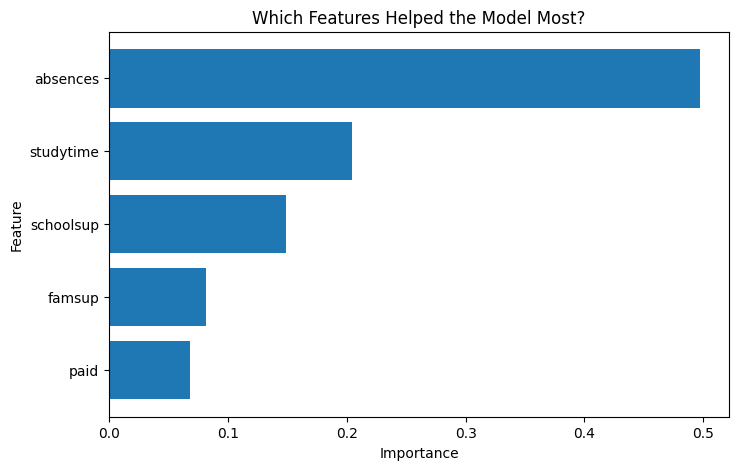

In [22]:
# ============================================================
# Step 16: Feature importance
#
# Feature importance tells us which inputs were most useful
# for the AI model.
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
print(feature_importance)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.title("Which Features Helped the Model Most?")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()



In [23]:
# ============================================================
# Step 17: Save the model
# ============================================================

import pickle

with open("student_performance_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved as student_performance_model.pkl")



Model saved as student_performance_model.pkl


In [24]:
# ============================================================
# Step 18: Reflection questions for final showcase
# ============================================================

reflection_questions = [
    "1. What problem does your AI model solve?",
    "2. What dataset did you use?",
    "3. What inputs did your model use?",
    "4. What does Pass mean in this project?",
    "5. What was your model accuracy?",
    "6. Which feature seemed most important?",
    "7. Did the model make any mistakes?",
    "8. How could this AI model be used responsibly?",
    "9. Why should humans be careful when using AI to make decisions about students?"
]

print("\nReflection Questions:")
for question in reflection_questions:
    print(question)



Reflection Questions:
1. What problem does your AI model solve?
2. What dataset did you use?
3. What inputs did your model use?
4. What does Pass mean in this project?
5. What was your model accuracy?
6. Which feature seemed most important?
7. Did the model make any mistakes?
8. How could this AI model be used responsibly?
9. Why should humans be careful when using AI to make decisions about students?


# ============================================================
# Presentation Template for Students
# ============================================================

presentation_template = """
Project Title:
Student Performance Prediction AI Model

Team Members:
[Names]

Problem:
We wanted to build an AI model that predicts whether a student may pass or need improvement.

Dataset:
We used the UCI Student Performance Dataset.
Dataset Link:
https://archive.ics.uci.edu/dataset/320/student%2Bperformance

Inputs:
Study time, absences, school support, family support, and extra classes.

Prediction:
Pass or Needs Improvement

Model Used:
Decision Tree Classifier

Result:
Our model reached approximately ____% accuracy.

Demo:
We entered a new student example, and the model predicted whether the student may pass or need improvement.

What We Learned:
We learned how AI can use data to make predictions, but also why humans must use AI responsibly.

Responsible AI Note:
This model should not be used to judge real students unfairly. It should only support learning and discussion.

Future Improvement:
We could include more useful features, collect better data, or use the model only as an early-warning support tool.
"""

print(presentation_template)